# Capacity Constraint

Goal: demonstrate, on hand-built instances, that the three solvers respect server capacities for CPU, RAM, storage and bandwidth.

In [16]:
from IPython.display import display

from vm_allocation.models import Context, Server, VM
from vm_allocation.solvers import CPSATSolver, FFDSolver, PLNESolver

## Feasible Instance

This instance is constrained enough to force the solvers to account for all four resources, while remaining feasible.

Available servers:
- small: cpu=8, ram=12, storage=80, bw=15
- medium: cpu=10, ram=16, storage=100, bw=20
- large: cpu=12, ram=20, storage=120, bw=25

VMs to place:
- 1: cpu=4, ram=4, storage=20, bw=5
- 2: cpu=7, ram=8, storage=50, bw=6
- 3: cpu=3, ram=3, storage=20, bw=4
- 4: cpu=5, ram=4, storage=40, bw=6
- 5: cpu=2, ram=2, storage=10, bw=2


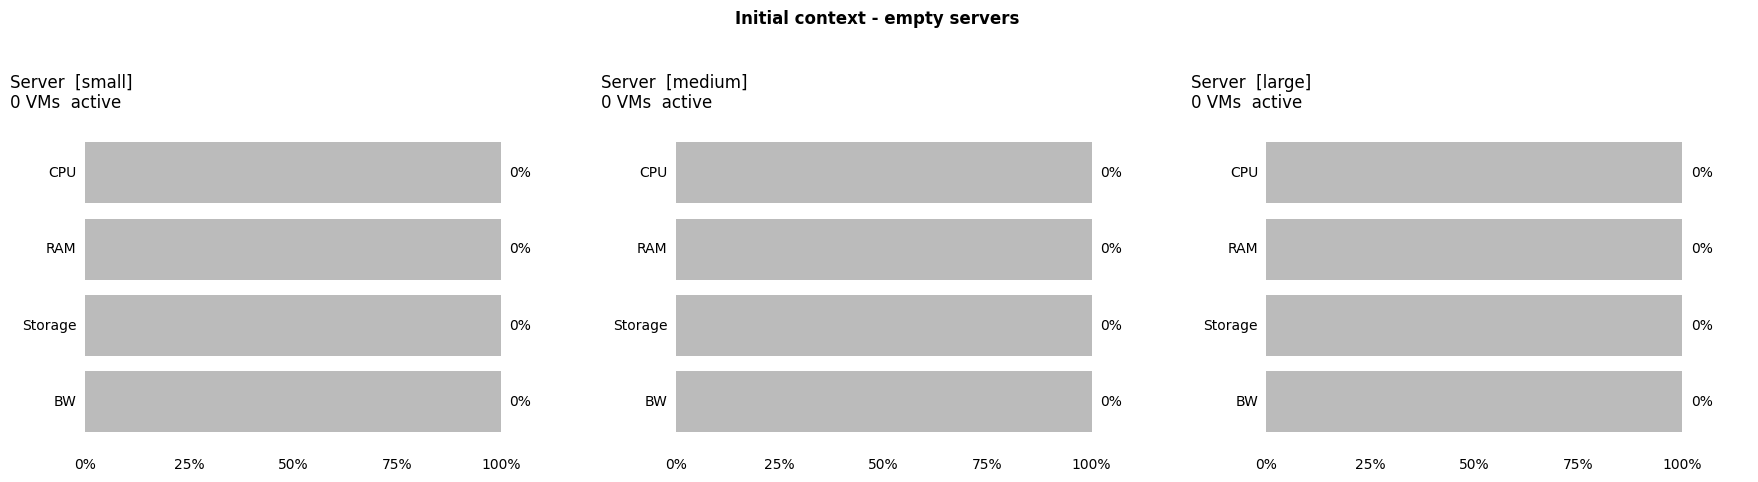

In [17]:
SERVERS = [
    Server("small", cpu=8, ram=12, storage=80, bw=15),
    Server("medium", cpu=10, ram=16, storage=100, bw=20),
    Server("large", cpu=12, ram=20, storage=120, bw=25),
]

VMS = [
    VM("1", cpu=4, ram=4, storage=20, bw=5),
    VM("2", cpu=7, ram=8, storage=50, bw=6),
    VM("3", cpu=3, ram=3, storage=20, bw=4),
    VM("4", cpu=5, ram=4, storage=40, bw=6),
    VM("5", cpu=2, ram=2, storage=10, bw=2),
]

SOLVERS = {
    "FFD": FFDSolver(),
    "PLNE": PLNESolver(),
    "CP-SAT": CPSATSolver(migration_weight=0, fragmentation_weight=0),
}


def copies(items):
    return [item.copy() for item in items]


print("Available servers:")
for server in SERVERS:
    print(f"- {server.id}: cpu={server.cpu_capacity}, ram={server.ram_capacity}, storage={server.storage_capacity}, bw={server.bw_capacity}")

print("\nVMs to place:")
for vm in VMS:
    print(f"- {vm.id}: cpu={vm.cpu}, ram={vm.ram}, storage={vm.storage}, bw={vm.bw}")

display(Context(copies(SERVERS)).plot("Initial context - empty servers"))

## Capacity Check

For each server in each solution, we check that every resource usage remains lower than or equal to its capacity.


===== FFD CLEAN SOLVER =====
[DEBUG] total VMs = 5

FFD - usage | capacity
Server    Resource    Usage   Capacity
----------------------------------------
small     CPU        7       8
small     RAM        8       12
small     Storage    50      80
small     BW         6       15
medium    CPU        9       10
medium    RAM        8       16
medium    Storage    60      100
medium    BW         11      20
large     CPU        5       12
large     RAM        5       20
large     Storage    30      120
large     BW         6       25


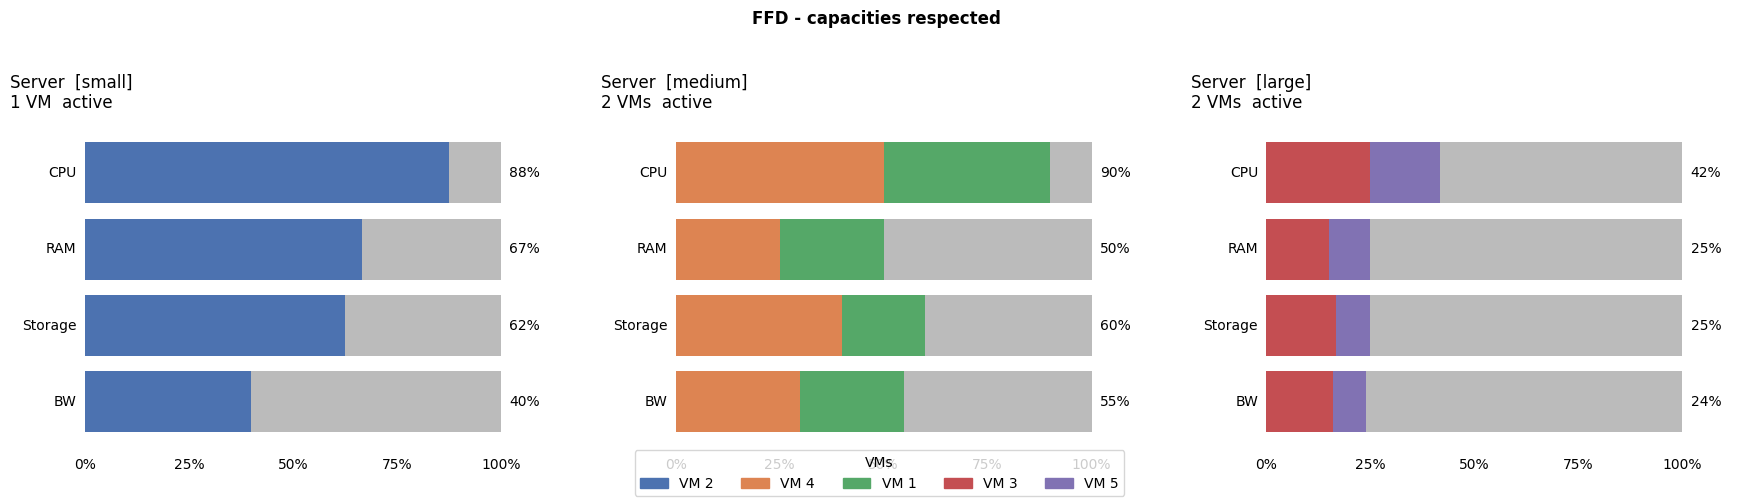


PLNE - usage | capacity
Server    Resource    Usage   Capacity
----------------------------------------
small     CPU        0       8
small     RAM        0       12
small     Storage    0       80
small     BW         0       15
medium    CPU        9       10
medium    RAM        9       16
medium    Storage    50      100
medium    BW         11      20
large     CPU        12      12
large     RAM        12      20
large     Storage    90      120
large     BW         12      25


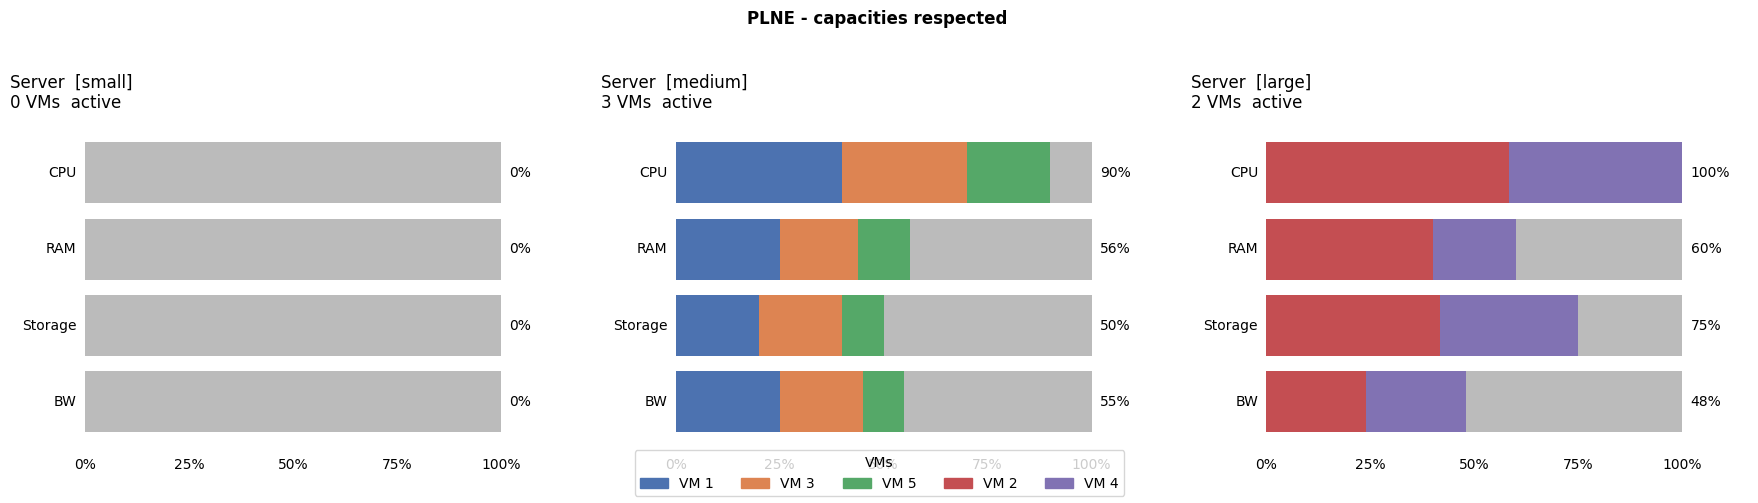


CP-SAT - usage | capacity
Server    Resource    Usage   Capacity
----------------------------------------
small     CPU        0       8
small     RAM        0       12
small     Storage    0       80
small     BW         0       15
medium    CPU        10      10
medium    RAM        9       16
medium    Storage    70      100
medium    BW         12      20
large     CPU        11      12
large     RAM        12      20
large     Storage    70      120
large     BW         11      25


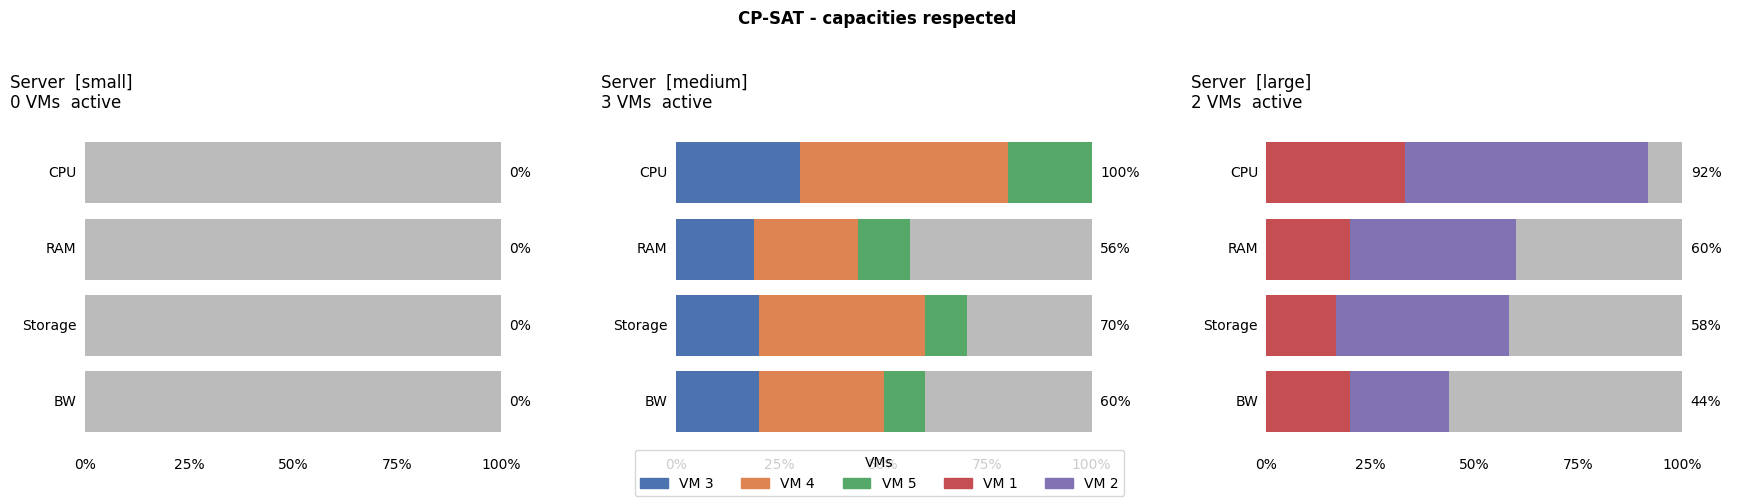


All solvers respect capacities on the feasible instance.


In [18]:
def resource_rows(context):
    for server in context.get_servers():
        yield server.id, "CPU", server.cpu_usage, server.cpu_capacity
        yield server.id, "RAM", server.ram_usage, server.ram_capacity
        yield server.id, "Storage", server.storage_usage, server.storage_capacity
        yield server.id, "BW", server.bw_usage, server.bw_capacity


solutions = {}

for solver_name, solver in SOLVERS.items():
    solution = solver.solve(copies(VMS), Context(copies(SERVERS)))
    assert solution is not None, f"{solver_name} did not find a feasible solution"

    rows = list(resource_rows(solution))
    violations = []

    for row in rows:
        server_id, resource, used, capacity = row
        if used > capacity:
            violations.append(row)

    assert not violations, violations
    solutions[solver_name] = solution

    print(f"\n{solver_name} - usage | capacity")
    print("Server    Resource    Usage   Capacity")
    print("----------------------------------------")
    for server_id, resource, used, capacity in rows:
        print(f"{server_id:<10}{resource:<11}{used:<8}{capacity}")

    display(solution.plot(f"{solver_name} - capacities respected"))

print("\nAll solvers respect capacities on the feasible instance.")

## Impossible Instance

We add a VM whose CPU requirement exceeds the capacity of every server. The solvers must reject the instance instead of producing an allocation that violates capacity.

In [19]:
oversized_vm = VM("oversized-cpu", cpu=13, ram=4, storage=20, bw=2)

for solver_name, solver in SOLVERS.items():
    solution = solver.solve([oversized_vm.copy()], Context(copies(SERVERS)))
    assert solution is None, f"{solver_name} should have rejected the oversized VM"
    print(f"{solver_name}: impossible instance correctly rejected")


===== FFD CLEAN SOLVER =====
[DEBUG] total VMs = 1
[FAIL] cannot place group
FFD: impossible instance correctly rejected
PLNE: impossible instance correctly rejected
CP-SAT: impossible instance correctly rejected


## Feasible Placement Details

In [20]:
for solver_name, solution in solutions.items():
    print(f"\n===== {solver_name} =====")
    print(solution)


===== FFD =====
===== Context - 3 servers, 5 VMs total =====

┌─ Server [small] ─── 1 VM ────────────────────────────────────────────────────────────────────┐
│  CPU     [████████████████████████████████████████████████████████░░░░░░░░]      7/8  ( 88%) │
│  RAM     [███████████████████████████████████████████░░░░░░░░░░░░░░░░░░░░░]     8/12  ( 67%) │
│  Storage [████████████████████████████████████████░░░░░░░░░░░░░░░░░░░░░░░░]    50/80  ( 62%) │
│  BW      [██████████████████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]     6/15  ( 40%) │
│  VMs:                                                                                        │
│    · VM[2](cpu=7, ram=8, sto=50, bw=6)                                                       │
└──────────────────────────────────────────────────────────────────────────────────────────────┘

┌─ Server [medium] ─── 2 VMs ──────────────────────────────────────────────────────────────────┐
│  CPU     [███████████████████████████████████████████████████